In [4]:
# import libraries
import numpy as np
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
import networkx as nx
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.linalg import cho_factor, cho_solve

from tqdm import tqdm

In [75]:
from functions import *

In [81]:
def visualize_graph_3d_plotly(edges, n_vertices, edge_weights=None, title="Graph (3D)"):
    """
    Interactive 3D graph visualization using Plotly.
    Fully rotatable — drag to explore the graph structure.
    Node size and color reflect degree.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))
    G.add_edges_from(edges)

    degrees = dict(G.degree())

    # 3D spring layout using networkx 2D + spectral for z
    pos_2d = nx.spring_layout(G, seed=42, k=2)
    
    # use second eigenvector of laplacian for z coordinate (more meaningful than random)
    L_mat   = nx.laplacian_matrix(G).toarray().astype(float)
    eigvals, eigvecs = np.linalg.eigh(L_mat)
    z_coord = eigvecs[:, 1]  # Fiedler vector — captures graph structure in z

    pos_3d = {v: (pos_2d[v][0], pos_2d[v][1], z_coord[v]) for v in G.nodes()}

    # edge traces
    edge_x, edge_y, edge_z = [], [], []
    for (i, j) in G.edges():
        x0, y0, z0 = pos_3d[i]
        x1, y1, z1 = pos_3d[j]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(width=1, color='rgba(255,255,255,0.3)'),
        hoverinfo='none',
        showlegend=False
    )

    # node traces
    node_x       = [pos_3d[v][0] for v in G.nodes()]
    node_y       = [pos_3d[v][1] for v in G.nodes()]
    node_z       = [pos_3d[v][2] for v in G.nodes()]
    node_degrees = np.array([degrees[v] for v in G.nodes()])
    node_sizes = [3 + degrees[v] * 0.5 for v in G.nodes()]
    node_text    = [f"Vertex {v}<br>Degree: {degrees[v]}" for v in G.nodes()]

    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers+text' if n_vertices <= 50 else 'markers',
        hoverinfo='text',
        text=[str(v) for v in G.nodes()] if n_vertices <= 50 else None,
        hovertext=node_text,
        marker=dict(
            size=node_sizes,
            color=node_degrees,
            colorscale='Viridis',
            cmin=min(node_degrees),
            cmax=max(node_degrees),
            showscale=True,
            colorbar=dict(
                title=dict(text="Degree", font=dict(color="white")),
                tickfont=dict(color="white"),
                thickness=15
            ),
            line=dict(width=0.5, color='white'),
            opacity=0.9
        ),
    showlegend=False
    )

    plotly_fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=dict(text=title, font=dict(color='white', size=16)),
            paper_bgcolor='#0f1117',
            height=800,
            width=1200,
            scene=dict(
                xaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                yaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                zaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                bgcolor='#0f1117',
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            margin=dict(l=0, r=0, t=50, b=0)
        )
    )
    plotly_fig.show()
    return plotly_fig

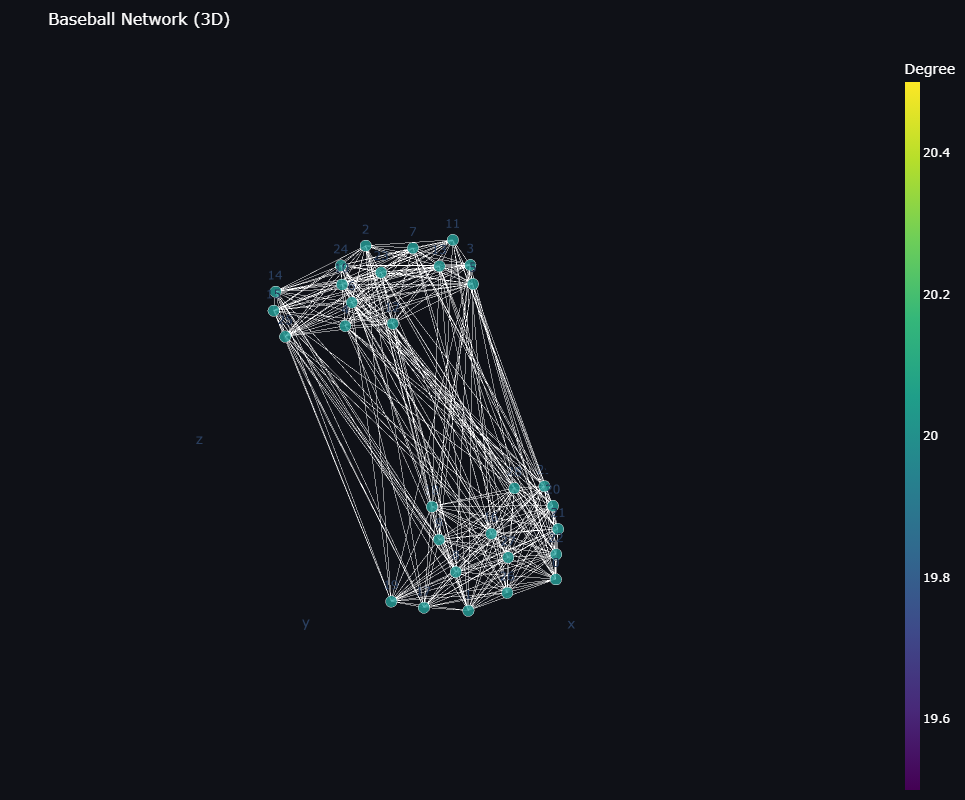

Saved


In [83]:
# call it
import plotly.io as pio
fig= visualize_graph_3d_plotly(edges, n_vertices, title="Baseball Network (3D)")
pio.write_html(fig, "baseball.html")
print("Saved")

In [6]:
# Load
edges, n_vertices, edge_weights = load_graph("./baseball (1).mtx")

✓ Loaded: ./baseball (1).mtx
  Vertices : 30
  Edges    : 300
  Weighted : yes



In [8]:
# Phase 1
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built and verified
  Matrix size : 30 x 30
  Degree range: [162, 162]



In [10]:
# Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min)

✓ lambda_min = 0.246914
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  Smallest eigenvalue of L_sigma: 10.000000



In [12]:
# Phase 3
np.random.seed(42)
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.0128, 0.0150]



In [14]:
# Phase 4
k = compute_permeability(u, edges, edge_weights)

✓ Phase 4 complete: permeabilities computed
  min k_e : 2.9752
  max k_e : 19.1869
  mean k_e: 8.1001



In [16]:
# Gamma in/out
degrees_arr = A.sum(axis=1)
gamma_in    = list(np.argsort(degrees_arr)[-5:])
gamma_out   = list(np.argsort(degrees_arr)[:5])

In [18]:
# Phase 5 & 6
L_k = build_weighted_laplacian(edges, n_vertices, k)
p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)
Q   = extract_qoi(p, k, edges, gamma_out)
print(f"Single sample Q = {Q:.6f}")

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

Single sample Q = 439.253790


In [29]:
from tqdm import tqdm

In [31]:
def monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None, N=1000):
    """
    Monte Carlo loop with tqdm progress bar.
    Runs Phases 3-6 N times and records Q each step.
    """
    B         = build_incidence_matrix(edges, n_vertices)
    cho_cache = cho_factor(L_sigma)
    Q_samples = np.zeros(N)

    with tqdm(total=N, desc="Monte Carlo", unit="sample") as pbar:
        for i in range(N):
            # Phase 3
            w = np.random.randn(len(edges))
            f = B @ w
            u = cho_solve(cho_cache, lambda_min * f)

            # Phase 4
            k = {(vi, vj): np.exp((u[vi] + u[vj]) / 2) *
                 (edge_weights.get((vi,vj), edge_weights.get((vj,vi), 1.0))
                  if edge_weights else 1.0)
                 for (vi, vj) in edges}

            # Phase 5
            L_k = build_weighted_laplacian(edges, n_vertices, k)
            p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

            # Phase 6
            Q_samples[i] = extract_qoi(p, k, edges, gamma_out)

            pbar.update(1)
            pbar.set_postfix({"mean Q": f"{Q_samples[:i+1].mean():.4f}"})

    print(f"\n✓ Done — {N} samples complete")
    print(f"  Mean Q : {Q_samples.mean():.6f}")
    print(f"  Std Q  : {Q_samples.std():.6f}")
    print(f"  Var Q  : {Q_samples.var():.6f}")

    return Q_samples


In [39]:
# Phase 7
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                   gamma_in, gamma_out, edge_weights=None, N=5000)

Monte Carlo:   0%|          | 5/5000 [00:00<01:49, 45.72sample/s, mean Q=52.7154] 

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo:   0%|          | 13/5000 [00:00<02:52, 28.97sample/s, mean Q=52.7330]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo:   0%|          | 21/5000 [00:00<02:10, 38.14sample/s, mean Q=52.7327]

...

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0

Monte Carlo: 100%|█████████▉| 4999/5000 [01:41<00:00, 59.42sample/s, mean Q=52.7225]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]



Monte Carlo: 100%|██████████| 5000/5000 [01:41<00:00, 49.25sample/s, mean Q=52.7225]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]


✓ Done — 5000 samples complete
  Mean Q : 52.722532
  Std Q  : 0.049009
  Var Q  : 0.002402



=== Monte Carlo Results ===
  Samples : 5000
  Mean Q  : 52.722532
  Std Q   : 0.049009
  Var Q   : 0.002402
  Min Q   : 52.556491
  Max Q   : 52.895357


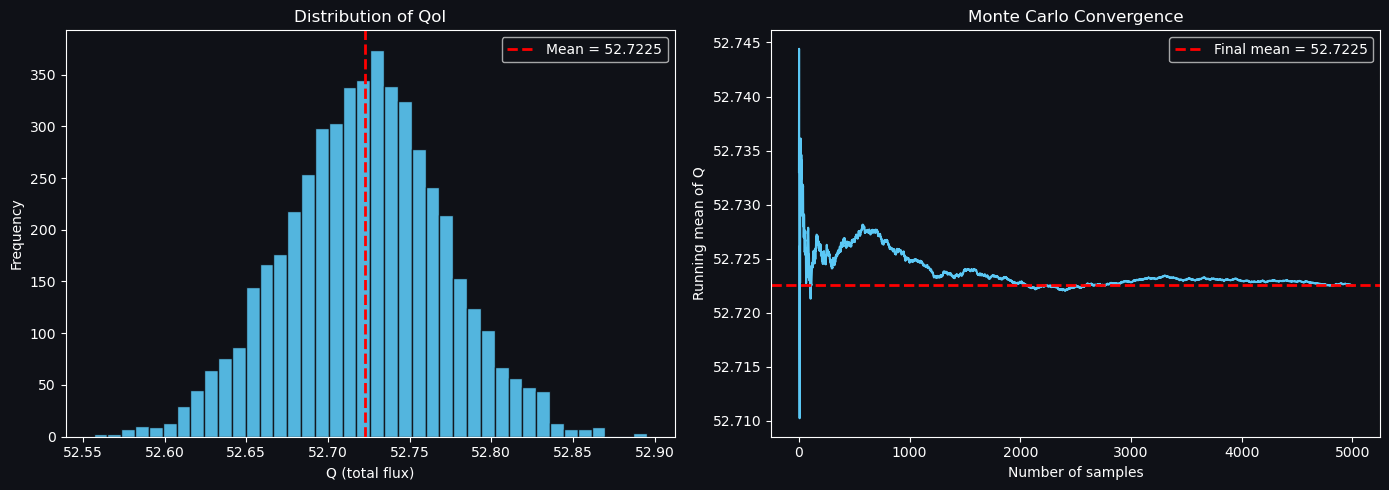

In [41]:
analyze_qoi(Q_samples)